# Data Curation with values

## Setup

In [1]:
!git clone https://huggingface.co/spaces/uc-ctds/ai_assisted_data_curation_toolkit

fatal: destination path 'ai_assisted_data_curation_toolkit' already exists and is not an empty directory.


In [2]:
# sqlite fix for chroma
import pysqlite3 as sqlite3
import sys
sys.modules['sqlite3'] = sys.modules.pop('pysqlite3')

In [3]:
import chromadb
import ast
import os
import json
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import chain
from scipy.stats import ks_2samp
from scipy.stats import mannwhitneyu


In [4]:
from ai_harmonization.simple_data_model import SimpleDataModel
from sentence_transformers import SentenceTransformer, util 
st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

/home/aartiv/ai-harmonization/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Use a Harmonization Approach with values to get Suggestions

### Get Input Data

- A `target data model` you want to harmonize to
- We will use a test BIOLINCC study, where variables have values added
- The `target data model` example is the **NHLBI BioData Catalyst Gen3 Data Dictionary**


In [5]:
target_file = "../data/example_target_model_BDC.json"

with open(target_file, "r") as f:
    input_target_model = json.load(f)

input_target_model = SimpleDataModel.get_from_unknown_json_format(
    json.dumps(input_target_model)
)

In [6]:
print("Target Model")
input_target_model.get_property_df()

Target Model


,node_name,property_name,property_description,property_type,additional_metadata
0,acknowledgement,acknowledgee,The indvidiual or group being acknowledged by ...,string,None
1,acknowledgement,created_datetime,,,None
2,acknowledgement,id,,string,None
3,acknowledgement,project_id,,string,None
4,acknowledgement,projects,,,None
...,...,...,...,...,...
823,submitted_unaligned_reads,read_groups,,,None
824,submitted_unaligned_reads,state,,,None
825,submitted_unaligned_reads,submitter_id,A project-specific identifier for a node. This...,[string],None
826,submitted_unaligned_reads,type,,string,None


In [7]:
target_df = input_target_model.get_property_df()

In [8]:
def format_node_name_property_name_prop_description(row):
    return f"{row['node_name']}.{row['property_name']} ({row['property_type']}): {row['property_description']}"

In [9]:
def format_node_name_property_name_prop_description_v2(row):
    return f"{row['node_name']} {row['property_name']} {row['property_description']}"

In [10]:
target_df['node_name_prop_name_type_and_desc'] = target_df.apply(format_node_name_property_name_prop_description, axis=1)

In [11]:
target_df['node_name_prop_name_type_and_desc'].iloc[0]

'acknowledgement.acknowledgee (string): The indvidiual or group being acknowledged by the project.'

In [12]:
target_df.head(n=3)

,node_name,property_name,property_description,property_type,additional_metadata,node_name_prop_name_type_and_desc
0,acknowledgement,acknowledgee,The indvidiual or group being acknowledged by ...,string,None,acknowledgement.acknowledgee (string): The ind...
1,acknowledgement,created_datetime,,,None,acknowledgement.created_datetime ():
2,acknowledgement,id,,string,None,acknowledgement.id (string):


***Push to a collection***
- embed prop_name_and_description using bge

In [13]:
from FlagEmbedding import FlagModel
model = FlagModel('BAAI/bge-large-en-v1.5', use_fp16=True)
# custom embedding model
# model = FlagModel('uc-ctds/bge-large-en-v1.5-bio-mapping', use_fp16=True)
models = {
    "node_name_prop_name_type_and_desc": FlagModel('BAAI/bge-large-en-v1.5')
}

In [14]:
embeddings = {
    'node_name_prop_name_type_and_desc': models['node_name_prop_name_type_and_desc'].encode(target_df['node_name_prop_name_type_and_desc'].tolist())
}

pre tokenize: 100%|██████████| 2/2 [00:00<00:00, 96.92it/s]
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
pre tokenize: 100%|██████████| 2/2 [00:00<00:00, 87.12it/s]
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
Chunks: 100%|██████████| 2/2 [00:04<00:00,  2.13s/it]


In [15]:
len(embeddings['node_name_prop_name_type_and_desc'])

828

In [16]:
client = chromadb.Client()

In [17]:
try:
    # delete collection if already exists
    client.delete_collection(name='prop_name_desc')
except Exception:
    print('collection does not exist, do nothing')

collection does not exist, do nothing


In [18]:
collection = client.create_collection("prop_name_desc", metadata={"hnsw:space": "cosine"})

In [19]:
batch_size = 5000
for i in range(0, target_df.shape[0], batch_size):
    print(f'adding records to collection, from {i} to {i+batch_size}')
    # just supply a list of embeddings and metadata to chroma
    # see https://docs.trychroma.com/docs/collections/add-data
    collection.add(
        embeddings=embeddings['node_name_prop_name_type_and_desc'][i:i+batch_size].tolist(),
        ids=target_df['node_name_prop_name_type_and_desc'][i:i+batch_size].tolist()
        #metadatas=target_df.to_dict("records")[i:i+batch_size]
    )

adding records to collection, from 0 to 5000


In [20]:
def get_combined_query_emb(query_var_name, query_var_desc):
    # init to 0
    query_var_name_desc = ' : '.join([query_var_name, query_var_desc])
    query_combined_emb = models['node_name_prop_name_type_and_desc'].encode(query_var_name_desc)
    return query_combined_emb

In [21]:
def get_top_k(query_combined_emb, k):
    results = collection.query(
        query_embeddings=query_combined_emb,
        n_results=k
    )
    return results

In [22]:
from types import SimpleNamespace
def init_query_vars():
    query_var_name = ''
    query_var_desc = ''
    query_var_type = ''
    query_var_val_cat = ''
    query_var_val_num = ''
    return SimpleNamespace(
        query_var_name=query_var_name,
        query_var_desc=query_var_desc,
        query_var_type=query_var_type,
        query_var_val_cat=query_var_val_cat,
        query_var_val_num=query_var_val_num
)

In [23]:
def return_top_k_results(row, k):
    query_var_name = str(row['source_name'])
    query_var_desc = str(row['source_desc'])
    query_vars = init_query_vars()
    query_vars.query_var_name = query_var_name
    #print(f'name,desc: {query_var_name}, {query_var_desc}')
    query_combined_emb = get_combined_query_emb(query_vars.query_var_name, query_vars.query_var_desc)
    results = get_top_k(query_combined_emb, k)
    return results

In [24]:
def format_results(results):
    formatted_results_df = pd.DataFrame({
        'ids': results['ids'][0],
        'distances': results['distances'][0]
    })
    formatted_results_df.sort_values(by='distances', ascending=True, inplace=True)
    formatted_results_df['names'] = formatted_results_df['ids'].apply(lambda x: x.split(' ')[0])
    return pd.Series([
        formatted_results_df['ids'].to_list(),
        formatted_results_df['distances'].to_list(),
        formatted_results_df['names'].to_list()
    ])

In [25]:
def process_benchmark(benchmark_name):
    df = pd.read_csv(benchmark_name, index_col=0, sep='\t')
    df = df.dropna(subset=['source_name', 'source_desc', 'source_values'])
    # embed query variables -- var name, var desc and return top_k
    # by searching CDE embeddings
    # print('embedding and retrieving data')
    top_k_list = [1, 5, 10]
    for k in top_k_list:
        col_name = f'top_{k}_results'
        # print(f'returning results for top {k}')
        df[col_name] = df.apply(lambda x: return_top_k_results(x, k=k), axis=1)
        # format results
        output_cols = f'top_{k}_ids,top_{k}_distances,top_{k}_names'.split(',')
        df[output_cols] = df[col_name].apply(
            lambda x: format_results(x)
        )
    print('returning top k results')
    return df


In [26]:
def calculate_acc(truth, pred, k):
  # print(f'calculating accuracy, k: {k}')
  correct = 0
  # print(f'truth: {truth}')
  # print(f'pred: {pred}')
  for t, p_list_of_names in zip(truth, pred):
      if t in p_list_of_names:
          correct += 1
  return correct / len(truth)

In [27]:
def calculate_acc_per_row(truth, pred):
    correct = 0
    if truth in pred:
        correct += 1
    return correct / len(truth)

In [28]:
def run_evals(df, benchmark_name, embedding_model):
    # print('calculating metrics')
    evals = {}
    row_index = []
    top_k_list = [1, 5, 10]
    for k in top_k_list:
        evals[f'accuracy_{k}'] = []
    for d in [df]:
        row_index.append(f'{benchmark_name}_{d.shape[0]}_{embedding_model}')
        for k in top_k_list:
            col_name = f'top_{k}_names'
            top_k_names_list = d[col_name].to_list()
            truth_list = d['target_name'].to_list()
            accuracy = calculate_acc(truth_list, top_k_names_list, k)
            evals[f'accuracy_{k}'].append(accuracy)

    # print('returning metrics')
    return pd.DataFrame(evals, index=row_index)

In [29]:
def run_evals_per_row(row, k):
    col_name = f'top_{k}_names'
    top_k_names_list = row[col_name]
    truth = row['target_name']
    is_match = truth in top_k_names_list
    return is_match

In [30]:
def get_metrics_per_row(df, benchmark_name):
    print('processing {}'.format(benchmark_name))
    output_file = benchmark_name.split('.csv')[0] + '.metrics_per_row.csv'
    print(output_file)
    top_k_list = [5]
    for k in top_k_list:
        output_cols = f'is_match_in_top_{k}_name_desc'
        df[output_cols] = df.apply(lambda x: run_evals_per_row(x, k), axis=1)
    cols_to_keep = [
    'source_name', 'source_desc', 'source_values', 'source_type',
    'target_name', 'target_values', 'top_5_results', 'top_5_ids', 'top_5_distances',
    'top_5_names',  'is_match_in_top_5_name_desc'
    ]
    metrics_per_row = df[cols_to_keep]
    metrics_per_row.to_csv(output_file, sep='\t')
    return metrics_per_row

### Evals

In [31]:
benchmark_names = ['../data/phs003738.source.csv', '../data/phs003948.source.csv', '../data/phs004055.source.csv']
embedding_model = 'bge'

### baseline results

In [32]:
results = pd.concat([
    run_evals(df=process_benchmark(eval_data), benchmark_name=eval_data, embedding_model=embedding_model)
    for eval_data in benchmark_names
])

You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


returning top k results
returning top k results
returning top k results


In [33]:
results

,accuracy_1,accuracy_5,accuracy_10
../data/phs003738.source.csv_50_bge,0.180000,0.320000,0.320000
../data/phs003948.source.csv_26_bge,0.115385,0.307692,0.307692
../data/phs004055.source.csv_43_bge,0.232558,0.488372,0.558140


# Compare histogram of values

In [34]:
def convert_str_to_dict(value_str):
    if pd.isna(value_str):
        return {}
    try:
        return ast.literal_eval(value_str)
    except (ValueError, SyntaxError):
        return {}

In [35]:
def flatten_values(row, df_name):
    hist_key_values = row['converted_values']
    datatype = df_name + '_type'
    flattened = []
    try:
        if datatype == 'number':
            for k, v in hist_key_values.items():
                flattened.append([int(k)] * v)
        else:
            for k, v in hist_key_values.items():
                flattened.append([k] * v)
        single_flattened_list = sorted(list(chain.from_iterable(flattened)))
    except Exception as e:
        single_flattened_list = np.nan
    return single_flattened_list

In [36]:
def get_top_k_numeric_matches(row, df, k):
    target_df_numeric_copy = df.copy()
    source_values = row['flattened_values']
    p_value_list = []
    for idx_t, row_t in target_df_numeric_copy.iterrows():
        target_values = row_t['flattened_values']
        p_value = float(ks_2samp(data1=source_values, data2=target_values).pvalue)
        #p_value = float(mannwhitneyu(source_values, target_values).pvalue)
        p_value_list.append(p_value)
    #print(sorted(p_value_list, reverse=True))
    target_df_numeric_copy['pvalue'] = p_value_list
    target_df_numeric_copy.sort_values(by=['pvalue'], ascending=False, inplace=True)
    top_k_pvalues = target_df_numeric_copy.iloc[:k]['pvalue'].to_list()
    top_k_target_names = target_df_numeric_copy.iloc[:k]['target_name'].to_list()
    top_k_target_values = target_df_numeric_copy.iloc[:k]['flattened_values'].to_list()
    
    # print(top_k_pvalues, top_k_target_names)
    return pd.Series([
        top_k_pvalues, top_k_target_names, top_k_target_values
    ])

In [37]:
def get_top_k_string_matches(source_values_string, target_string_embeddings, target_df_only_string, top_k):
    query_embedding = st_model.encode(source_values_string, convert_to_tensor=True)
    cosine_scores = util.cos_sim(query_embedding, target_string_embeddings)
    top_results = torch.topk(cosine_scores, k=top_k)
    top_results_scores = top_results.values.tolist()[0]
    top_results_indices = top_results.indices.tolist()[0]
    top_k_target_names = target_df_only_string.loc[top_results_indices, 'target_name'].to_list()
    #print(top_results_scores, top_results_indices, top_k_target_names)
    return pd.Series([
        top_results_scores, top_results_indices, top_k_target_names
    ])

In [38]:
def get_target_string_embeddings(df, data_to_include):
    if data_to_include == 'all_flattened_values':
        target_rows = df['flattened_values'].to_list()
        target_embeddings = st_model.encode(target_rows, convert_to_tensor=True)
    else:
        target_rows = df['unique_keys'].to_list()
        target_rows_processed = [",".join(item) for item in target_rows]
        target_embeddings = st_model.encode(target_rows_processed, convert_to_tensor=True)
    return target_embeddings

In [39]:
def compare_cols(row, colname1, colname2):
    a = row[colname1]
    b = row[colname2]
    if a == True and b == False:
        return a
    elif a == False and b == True:
        return b
    elif pd.isna(a) and b in [True, False]:
        return b
    elif pd.isna(b) and a in [True, False]:
        return a
    else:
        return False


In [40]:
def make_plot(b, metrics_per_row_with_numeric_string):
    plot_outfilename = b.split('/')[-1] + '_vals.png'
    plot_outfilepath = os.path.join('../figs', plot_outfilename)

    exclude_no_target_values = metrics_per_row_with_numeric_string[metrics_per_row_with_numeric_string['is_target_values'] == 'TRUE']

    accuracy = [
        float(exclude_no_target_values['is_match_in_top_5_name_desc'].value_counts(normalize=True).loc[True]),
        float(exclude_no_target_values['is_match_in_top_5_numeric_or_string_vals'].value_counts(normalize=True).loc[True]),
        float(exclude_no_target_values['is_match_in_top10_name_desc_val'].value_counts(normalize=True).loc[True])
    ]
    labels = ["name+desc\nk=5", "values\nk=5", "name+desc+values\nk=10"]

    plt.figure(figsize=(5,4))
    plt.bar(labels, accuracy, width=0.3)
    plt.ylabel("Accuracy (Recall)")
    plt.title(f'BIOLINCC benchmark {b}')
    plt.tight_layout()
    plt.savefig(plot_outfilepath, dpi=300)

processing benchmark ../data/phs003738.source.csv
returning top k results
processing ../data/phs003738.source.csv
../data/phs003738.source.metrics_per_row.csv
comparing numeric vectors


/tmp/ipykernel_591963/2260271006.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_value = float(ks_2samp(data1=source_values, data2=target_values).pvalue)
/tmp/ipykernel_591963/2260271006.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_value = float(ks_2samp(data1=source_values, data2=target_values).pvalue)
/tmp/ipykernel_591963/2260271006.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_value = float(ks_2samp(data1=source_values, data2=target_values).pvalue)
/tmp/ipykernel_591963/2260271006.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_value = float(ks_2samp(data1=sour

comparing categorical vectors
plotting results
processing benchmark ../data/phs003948.source.csv
returning top k results
processing ../data/phs003948.source.csv
../data/phs003948.source.metrics_per_row.csv
comparing numeric vectors


/tmp/ipykernel_591963/2260271006.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_value = float(ks_2samp(data1=source_values, data2=target_values).pvalue)
/tmp/ipykernel_591963/2260271006.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_value = float(ks_2samp(data1=source_values, data2=target_values).pvalue)
/tmp/ipykernel_591963/2260271006.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_value = float(ks_2samp(data1=source_values, data2=target_values).pvalue)


comparing categorical vectors
plotting results
processing benchmark ../data/phs004055.source.csv
returning top k results
processing ../data/phs004055.source.csv
../data/phs004055.source.metrics_per_row.csv
comparing numeric vectors


/tmp/ipykernel_591963/2260271006.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_value = float(ks_2samp(data1=source_values, data2=target_values).pvalue)
/tmp/ipykernel_591963/2260271006.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_value = float(ks_2samp(data1=source_values, data2=target_values).pvalue)
/tmp/ipykernel_591963/2260271006.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_value = float(ks_2samp(data1=source_values, data2=target_values).pvalue)
/tmp/ipykernel_591963/2260271006.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_value = float(ks_2samp(data1=sour

comparing categorical vectors
plotting results


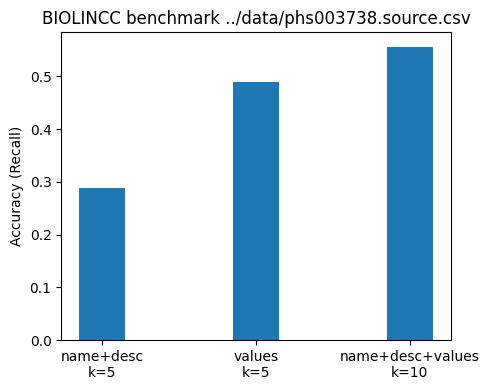

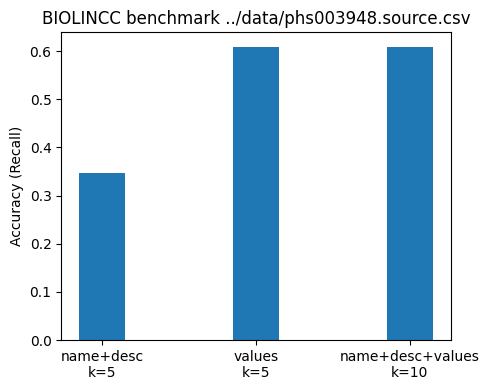

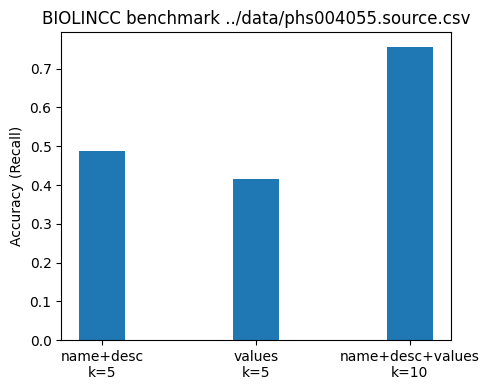

In [41]:
for b in benchmark_names:
    print('processing benchmark {}'.format(b))
    df = process_benchmark(benchmark_name=b)
    metrics_per_row = get_metrics_per_row(df, benchmark_name=b)

    source_df = pd.read_csv(b, sep='\t', index_col=0)
    target_df = pd.read_csv(b.split('.source.csv')[0] + '.target.csv', sep='\t', index_col=0)
    source_df.dropna(subset=['source_name', 'source_desc', 'source_values'], inplace=True)
    
    # flatten source and target values
    source_df['converted_values'] = source_df['source_values'].apply(convert_str_to_dict)
    target_df['converted_values'] = target_df['target_values'].apply(convert_str_to_dict)
    source_df['flattened_values'] = source_df.apply(lambda row: flatten_values(row, df_name = 'source'), axis=1)
    target_df['flattened_values'] = target_df.apply(lambda row: flatten_values(row, df_name = 'target'), axis=1)
    
    # numeric dist comparisons
    print('comparing numeric vectors')
    source_df_only_numeric = source_df[source_df['source_type'] == 'number'].copy()
    target_df_only_numeric = target_df[target_df['target_type'] == 'number'].copy()
    source_df_only_numeric[['top_k_pvalues', 'top_k_target_names', 'top_k_target_values']] = source_df_only_numeric.apply(
        lambda x: get_top_k_numeric_matches(x, target_df_only_numeric, 5), axis=1)
    source_df_only_numeric['is_match_in_top_k'] = source_df_only_numeric.apply(lambda row: row['target_name'] in row['top_k_target_names'], axis=1)
    keep_cols = ['source_name', 'source_desc', 'target_name', 'target_values', 'top_k_target_names', 'top_k_pvalues', 'is_match_in_top_k']
    numeric_output_file = b.split('.csv')[0] + '.only_numeric.csv'
    source_df_only_numeric.to_csv(numeric_output_file, columns=keep_cols)
    
    # categorical value comparisons
    print('comparing categorical vectors')
    source_df_only_string = source_df[source_df['source_type'] == 'string'].copy()
    target_df_only_string = target_df[target_df['target_type'] == 'string'].copy()
    source_df_only_string['flattened_values'] = source_df_only_string['flattened_values'].apply(lambda x: np.nan if isinstance(x, list) and len(x) == 0 else x)
    target_df_only_string['flattened_values'] = target_df_only_string['flattened_values'].apply(lambda x: np.nan if isinstance(x, list) and len(x) == 0 else x)
    target_df_only_string.dropna(subset=['flattened_values'], inplace=True)
    target_df_only_string = target_df_only_string.reset_index(drop=True)
    source_df_only_string['unique_keys'] = source_df_only_string['flattened_values'].apply(lambda x: list(set(x)))
    target_df_only_string['unique_keys'] = target_df_only_string['flattened_values'].apply(lambda x: list(set(x)))
    target_string_embeddings = get_target_string_embeddings(target_df_only_string, data_to_include='all_flattened_values')
    # change to flattened_values column for both keys and values
    source_df_only_string[['top_results_scores', 'top_results_indices', 'top_k_target_names']] = source_df_only_string['flattened_values'].apply(
        lambda x: get_top_k_string_matches(x, target_string_embeddings, target_df_only_string, 5))
    source_df_only_string['is_match_in_top_k'] = source_df_only_string.apply(lambda row: row['target_name'] in row['top_k_target_names'], axis=1)
    source_df_only_string.to_csv(b.split('.csv')[0] + '.only_string.csv', sep='\t')
    
    # plot results
    print('plotting results')
    source_df_only_numeric.rename(columns={
        'is_match_in_top_k': 'is_match_in_top_5_numeric_vals',
        'top_k_target_names': 'top_5_target_names_numeric_vals'
        }, 
        inplace=True
    )
    source_df_only_string.rename(columns={
        'is_match_in_top_k': 'is_match_in_top_5_string_vals',
        'top_k_target_names': 'top_5_target_names_string_vals'
        }, 
        inplace=True
    )
    metrics_per_row_join_numeric = pd.merge(
        left=metrics_per_row,
        right=source_df_only_numeric,
        on=['source_name', 'source_desc', 'source_values', 'target_name', 'target_values', 'source_type'],
        how='left'
    )
    metrics_per_row_with_numeric_string = pd.merge(
        left=metrics_per_row_join_numeric,
        right=source_df_only_string,
        on=['source_name', 'source_desc', 'source_values', 'target_name', 'target_values', 'source_type'],
        how='left'
    )
    col_subset = ['source_name', 'source_desc', 'source_values', 'source_type',
              'target_name', 'target_values', 'top_5_names', 'is_match_in_top_5_name_desc',
              'top_5_target_names_numeric_vals', 'is_match_in_top_5_numeric_vals',
              'top_5_target_names_string_vals', 'is_match_in_top_5_string_vals'
              ]
    metrics_per_row_with_numeric_string = metrics_per_row_with_numeric_string[col_subset]
    metrics_per_row_with_numeric_string['is_match_in_top_5_numeric_or_string_vals'] = metrics_per_row_with_numeric_string.apply(
        lambda x: compare_cols(x, colname1='is_match_in_top_5_numeric_vals', colname2='is_match_in_top_5_string_vals'), axis=1)
    metrics_per_row_with_numeric_string['is_match_in_top10_name_desc_val'] = metrics_per_row_with_numeric_string.apply(
        lambda x: compare_cols(x, colname1='is_match_in_top_5_numeric_or_string_vals', colname2='is_match_in_top_5_name_desc'),
        axis=1
    )
    # filter out rows with null target values
    metrics_per_row_with_numeric_string['is_target_values'] = metrics_per_row_with_numeric_string['target_values'].apply(
        lambda x: 'FALSE' if len(ast.literal_eval(x)) == 0 else 'TRUE'
    )
    make_plot(b, metrics_per_row_with_numeric_string)

## TO-DO
- figure out simple encoding of true/false in benchmark
- add custom embedding models